# Burst Detection
We will implement burst detection using the **string method**, a technique for identifying bursts of neuronal activity based on the temporal structure of spike trains. This method detects sequences of spikes that meet specific criteria for interspike intervals and burst duration.

*  A burst is characterized by a certain number of spikes: the minimum number of spikes belonging to a burst needs to be defined.
*   Spikes in a burst are very close: a maximum inter-spike interval (ISI) value has to be set, to consider a spike as a part of a burst or not.
*   Bursts are separated by hundreds of milliseconds: a minimum inter-burst interval (IBI) has to be set, to consider 2 bursts as separated or not.

For simplicity, IBImin = ISImax = 100 ms.


In [24]:
# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Import libraries
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.sparse import issparse

def plot_spike_train(spike_train, fs, ax):
    """
    Plot a spike train.

    Args:
      spike_train (numpy array): Spike times in samples.
      fs (float): Sampling frequency in Hz.
      ax (matplotlib.axes.Axes): Axes object to plot the results.
    """
    time_axis = np.arange(spike_train.size) / fs
    ax.plot(time_axis, spike_train, lw=.1, color='k')
    ax.set(xlabel='Time (s)', ylabel='Spike')
    ax.set_yticks([])
    ax.spines[['top', 'right']].set_visible(False)

## Load and plot the data
The sampling frequency of the data is 10 kHz.

Before performing burst detection, make sure you have a dense array.


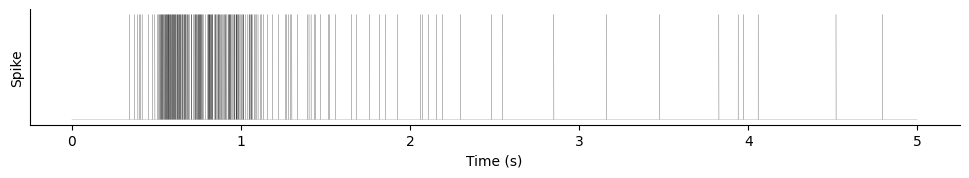

In [25]:
peak_train = scipy.io.loadmat('./ptrain_34337_DIV98_100E_nbasal_0001_056.mat', squeeze_me=True)['peak_train']
sfreq = 10000 # Hz
def convert_to_dense(sparse_array):
  """
  Convert a sparse array to a dense array.

  Args:
    sparse_array (numpy array): A sparse array.
  Returns:
    A 1D numpy dense array.
  """
  if issparse(sparse_array):
      return sparse_array.toarray().flatten()
  else:
      return np.asarray(sparse_array).flatten()

# Convert to dense array
peak_train = convert_to_dense(peak_train)
peak_train = peak_train[0:5*sfreq] # only the first 50 seconds

peak_train[peak_train > 0] = 1
timestamps = np.where(peak_train)[0]

fig, ax = plt.subplots(1, 1, figsize=(12, 1.5))
plot_spike_train(peak_train, sfreq, ax)

## Burst detection implementation

In [26]:
def detect_bursts(timestamps, sfreq, maxISI=100e-3, minintraburstspikes=5):
    """
    Detects burst events in a spike train with the string method.

    Args:
        timestamps (numpy array): Spike times in samples.
        sfreq (float): Sampling frequency in Hz.
        maxISI (float): Maximum interspike interval in seconds.
        minintraburstspikes (int): Minimum number of spikes in a burst.

    Returns:
        burst_start (list): List of burst start indices.
        burst_end (list): List of burst end indices.
    """
    times = timestamps / sfreq
    N = len(timestamps)
    burst_start = []
    burst_end = []
    i = 0
    while (i+minintraburstspikes-1) < N:
        if times[i+minintraburstspikes-1] - times[i] < minintraburstspikes * maxISI:
            burst_start.append(timestamps[i])
            i += minintraburstspikes
            while i < N and times[i] - times[i-1] <= maxISI:
                i += 1
            burst_end.append(timestamps[i-1])
        else:
            i += 1
    return burst_start, burst_end

# Burst detection
maxISI = 0.1  # s
minintraburstspikes = 5
burst_start, burst_end = detect_bursts(timestamps, sfreq, maxISI, minintraburstspikes)

## Plot burst detection

3410 19250
20618 21904


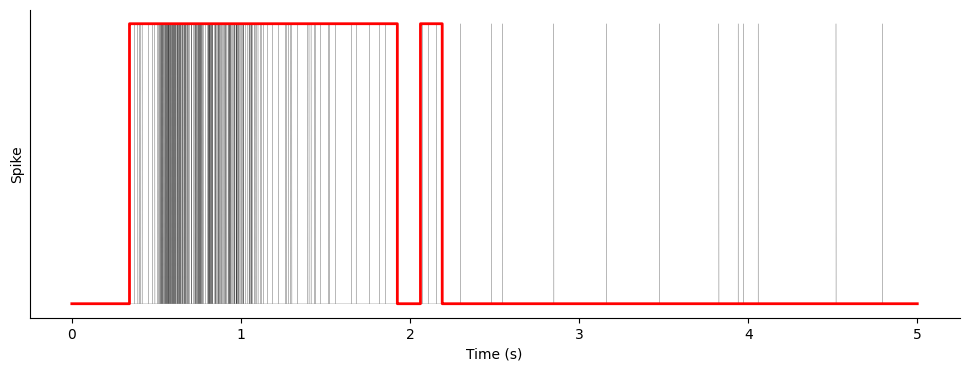

In [27]:
def plot_burst_detection(burst_start, burst_end, sfreq, peak_train, ax):
    """
    Plots burst detection results alongside spike train.
    """
    time_axis = np.arange(peak_train.size) / sfreq
    ax.plot(time_axis, peak_train, lw=.1, color='k')
    ax.set(xlabel='Time (s)', ylabel='Spike')
    ax.set_yticks([])
    ax.spines[['top', 'right']].set_visible(False)
    rect = np.zeros_like(peak_train)
    for i in range(len(burst_start)):
        rect[burst_start[i]:burst_end[i]] = 1  
        print(burst_start[i], burst_end[i])      
    plt.step(time_axis, rect, where='post', color='r', linewidth=2)

# Plot results
fig, axs = plt.subplots(1, 1, figsize=(12, 4))
plot_burst_detection(burst_start, burst_end, sfreq, peak_train, axs)
